# Synthetic Retail Demand Dataset Generation

This notebook generates a synthetic one-year historical retail demand dataset for a retail operations analytics portfolio project.

The dataset is designed to be business-plausible rather than perfectly realistic. It simulates common retail demand drivers such as:

- Store type differences
- Product and category differences
- Weekday/weekend patterns
- Seasonal demand
- Public holidays and event windows
- Store closures and reduced trading
- Product-level supply disruptions
- Random daily demand variation

The exported outputs are designed for Power BI. They keep business-facing fields such as date, store, product, units, sales, event flags, trading status and disruption flags. Technical generation factors such as multipliers, availability factors and random noise are kept inside the notebook and are not exported to the dashboard tables.


## 1. Import Libraries and Set Date Range

Import the required Python libraries, define the historical data period and set the export folder.

The generated historical dataset covers the full 2025 calendar year.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

np.random.seed(42)

START_DATE = "2025-01-01"
END_DATE = "2025-12-31"

dates = pd.date_range(START_DATE, END_DATE, freq="D")

OUTPUT_DIR = Path("../data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Create Product Table

Define the products included in the synthetic dataset.

Each product has business-facing attributes for Power BI, such as product ID, category and unit price. It also has internal generation assumptions such as baseline daily demand, event sensitivity and noise level.

The internal generation fields are used to create realistic demand patterns, but they are not exported to the Power BI product dimension.


In [2]:
products = pd.DataFrame({
    "product_id": [
        "P001", "P002", "P003", "P004", "P005",
        "P006", "P007", "P008", "P009", "P010"
    ],
    "product_name": [
        "Milk",
        "Bread",
        "Eggs",
        "Chocolate",
        "Ham",
        "Ice cream",
        "BBQ sausages",
        "Soup",
        "Olive oil",
        "Lettuce"
    ],
    "category": [
        "Dairy",
        "Bakery",
        "Dairy",
        "Confectionery",
        "Deli",
        "Frozen",
        "Meat",
        "Pantry",
        "Pantry",
        "Fresh Produce"
    ],
    "unit_price": [2.40, 3.20, 5.50, 4.00, 8.50, 6.00, 7.50, 3.80, 11.00, 2.80],

    # Internal generation assumptions
    # Normal daily unit demand before store, calendar, event, disruption and noise effects
    "baseline_units": [520, 430, 300, 180, 90, 220, 260, 210, 160, 240],

    # Random unexplained daily variation after known effects are applied
    "daily_noise_sd": [0.025, 0.030, 0.035, 0.060, 0.080, 0.070, 0.065, 0.055, 0.050, 0.070],

    # How strongly each product responds to weekly/weekend pattern
    "weekend_sensitivity": [0.4, 0.7, 0.4, 0.5, 0.7, 0.8, 1.1, 0.4, 0.3, 0.6],

    # How strongly each product responds to major retail events/seasons
    "christmas_sensitivity": [0.2, 0.4, 0.3, 0.8, 1.8, 0.5, 0.7, 0.2, 0.2, 0.3],
    "easter_sensitivity": [0.2, 0.4, 0.3, 1.8, 0.2, 0.3, 0.5, 0.1, 0.1, 0.3],
    "long_weekend_sensitivity": [0.1, 0.3, 0.2, 0.3, 0.4, 0.8, 1.2, 0.1, 0.1, 0.4],
    "school_holiday_sensitivity": [0.2, 0.3, 0.2, 0.6, 0.1, 0.8, 0.5, 0.1, 0.1, 0.3],

    # Seasonal response
    "summer_sensitivity": [0.0, 0.0, 0.0, 0.1, 0.0, 1.2, 1.0, -0.3, 0.0, 0.2],
    "winter_sensitivity": [0.0, 0.0, 0.0, 0.0, 0.0, -0.2, -0.2, 1.1, 0.0, -0.1],
})

product_dimension = products[["product_id", "product_name", "category", "unit_price"]].copy()


## 3. Create Store Table

Define the stores included in the synthetic dataset.

Each store has business-facing attributes for Power BI, such as store ID, store name, region and store type. It also has an internal store volume factor used to generate different normal demand levels across metro, suburban and regional stores.


In [3]:
stores = pd.DataFrame({
    "store_id": ["S001", "S002", "S003"],
    "store_name": ["Central Metro", "North Suburban", "West Regional"],
    "store_type": ["metro", "suburban", "regional"],
    "region": ["Central", "North", "West"],
    "state": ["NSW", "NSW", "NSW"],

    # Internal generation assumption: normal baseline volume difference by store type
    "store_factor": [1.15, 1.00, 0.80]
})

store_dimension = stores[["store_id", "store_name", "store_type", "region", "state"]].copy()


## 4. Create Base Feature Matrix

Create one row for every combination of:

`date × store × product`

This forms the full daily sales structure before demand effects are applied.

In [4]:
calendar = pd.DataFrame({"date": dates})

feature_matrix = (
    calendar
    .merge(stores, how="cross")
    .merge(products, how="cross")
)


## 5. Add Basic Calendar Features

Create basic calendar variables from the date:

- Day of week
- Month
- Season

These features are later used to model weekday and seasonal demand patterns.

In [5]:
def get_season(month):
    if month in [12, 1, 2]:
        return "summer"
    elif month in [3, 4, 5]:
        return "autumn"
    elif month in [6, 7, 8]:
        return "winter"
    else:
        return "spring"


feature_matrix["day_of_week"] = feature_matrix["date"].dt.day_name()
feature_matrix["month"] = feature_matrix["date"].dt.month
feature_matrix["season"] = feature_matrix["month"].apply(get_season)

## 6. Add Holiday and Event Features

Tag each date with a holiday type and event window.

The event windows capture important retail periods such as:

- New Year
- Australia Day long weekend
- Easter
- ANZAC Day
- King’s Birthday long weekend
- School holidays
- Christmas and end-of-year trading

These tags help create realistic demand changes around known calendar events. A cleaned event reference table is exported later for Power BI.


In [6]:
def get_event_features(date):
    """
    Creates holiday/event features.

    holiday_type = broad event family
    event_window = specific timing/context

    This captures not only the holiday itself, but also surrounding
    travel, stock-up, reduced-trading and recovery periods.
    """

    holiday_type = "none"
    event_window = "normal"

    # New Year period
    if pd.Timestamp("2025-01-01") <= date <= pd.Timestamp("2025-01-05"):
        holiday_type = "new_year"

        if date == pd.Timestamp("2025-01-01"):
            event_window = "new_years_day_reduced_trading"
        else:
            event_window = "new_year_travel_period"

    # Australia Day long weekend / travel period
    elif pd.Timestamp("2025-01-24") <= date <= pd.Timestamp("2025-01-28"):
        holiday_type = "long_weekend"

        if date == pd.Timestamp("2025-01-24"):
            event_window = "pre_long_weekend_stock_up"
        elif pd.Timestamp("2025-01-25") <= date <= pd.Timestamp("2025-01-27"):
            event_window = "long_weekend"
        else:
            event_window = "post_long_weekend"

    # Easter period
    elif pd.Timestamp("2025-04-10") <= date <= pd.Timestamp("2025-04-24"):
        holiday_type = "easter"

        if pd.Timestamp("2025-04-10") <= date <= pd.Timestamp("2025-04-17"):
            event_window = "easter_build_up"
        elif date == pd.Timestamp("2025-04-18"):
            event_window = "good_friday_closed"
        elif date == pd.Timestamp("2025-04-20"):
            event_window = "easter_sunday_closed"
        elif date == pd.Timestamp("2025-04-21"):
            event_window = "easter_monday_reduced_trading"
        elif pd.Timestamp("2025-04-18") <= date <= pd.Timestamp("2025-04-21"):
            event_window = "easter_long_weekend"
        else:
            event_window = "post_easter_normalisation"

    # ANZAC Day
    elif date == pd.Timestamp("2025-04-25"):
        holiday_type = "anzac"
        event_window = "anzac_day_closed"

    # King's Birthday
    elif pd.Timestamp("2025-06-06") <= date <= pd.Timestamp("2025-06-10"):
        holiday_type = "long_weekend"

        if pd.Timestamp("2025-06-06") <= date < pd.Timestamp("2025-06-07"):
            event_window = "pre_long_weekend_stock_up"
        elif pd.Timestamp("2025-06-07") <= date <= pd.Timestamp("2025-06-09"):
            event_window = "long_weekend"
        else:
            event_window = "post_long_weekend"

    # Winter school holidays
    elif pd.Timestamp("2025-07-07") <= date <= pd.Timestamp("2025-07-20"):
        holiday_type = "school_holiday"
        event_window = "winter_school_holiday"

    # Spring school holidays
    elif pd.Timestamp("2025-09-29") <= date <= pd.Timestamp("2025-10-12"):
        holiday_type = "school_holiday"
        event_window = "spring_school_holiday"

    # Christmas / end-of-year period
    elif pd.Timestamp("2025-12-10") <= date <= pd.Timestamp("2025-12-31"):
        holiday_type = "christmas"

        if pd.Timestamp("2025-12-10") <= date <= pd.Timestamp("2025-12-18"):
            event_window = "early_christmas_build_up"
        elif pd.Timestamp("2025-12-19") <= date <= pd.Timestamp("2025-12-24"):
            event_window = "peak_christmas_build_up"
        elif date == pd.Timestamp("2025-12-25"):
            event_window = "christmas_day_closed"
        elif pd.Timestamp("2025-12-26") <= date <= pd.Timestamp("2025-12-28"):
            event_window = "post_christmas"
        elif pd.Timestamp("2025-12-29") <= date <= pd.Timestamp("2025-12-31"):
            event_window = "new_years_eve_build_up"

    return holiday_type, event_window


feature_matrix[["holiday_type", "event_window"]] = feature_matrix["date"].apply(
    lambda d: pd.Series(get_event_features(d))
)

## 7. Add Weekend Type Feature

Classify each date as a normal weekday/weekend or an event-period weekday/weekend.

This separates normal weekends from special weekends such as Easter, Christmas/New Year, school holidays, or long weekends.

In [7]:
def get_weekend_type(day_of_week, event_window):
    """
    Captures that a normal weekend is different from an event-period weekend.
    """

    is_weekend = day_of_week in ["Saturday", "Sunday"]

    if not is_weekend:
        return "event_weekday" if event_window != "normal" else "normal_weekday"

    if event_window == "normal":
        return "normal_weekend"
    elif "christmas" in event_window or "new_year" in event_window:
        return "christmas_new_year_weekend"
    elif "easter" in event_window:
        return "easter_weekend"
    elif "school_holiday" in event_window:
        return "school_holiday_weekend"
    elif "long_weekend" in event_window:
        return "long_weekend"
    else:
        return "event_weekend"


feature_matrix["weekend_type"] = feature_matrix.apply(
    lambda r: get_weekend_type(r["day_of_week"], r["event_window"]),
    axis=1
)

## 8. Add Store Closure and Reduced-Trading Effects

Add trading status assumptions for closure and reduced-trading days.

Full closure days have zero trading capacity. Reduced-trading days have lower trading capacity.

These assumptions are used only to generate the historical synthetic sales data.

In [8]:
def get_trading_capacity(event_window):
    """
    Separates store trading constraints from product supply disruptions.

    is_store_closed:
        1 = assumed closed
        0 = assumed open

    trading_capacity_factor:
        1.00 = normal trading
        0.75 = reduced trading
        0.00 = closed
    """

    # Full closure assumptions
    if event_window in [
        "christmas_day_closed",
        "good_friday_closed",
        "easter_sunday_closed",
        "anzac_day_closed",
    ]:
        return 1, 0.00

    # Reduced trading assumptions
    if event_window in [
        "new_years_day_reduced_trading",
        "easter_monday_reduced_trading",
    ]:
        return 0, 0.75

    return 0, 1.00


feature_matrix[["is_store_closed", "trading_capacity_factor"]] = feature_matrix["event_window"].apply(
    lambda x: pd.Series(get_trading_capacity(x))
)

## 9. Add National Product-Level Supply Disruptions

Add selected product-level supply disruptions.

The disruptions are national, meaning they affect the same product across all stores during the same period.

Examples include:

- Olive oil supply shortage
- Fresh produce weather disruption
- Seasonal import delay

These disruption effects are used to generate lower observed sales during abnormal supply periods.

In [9]:
def disruption_curve(date, start, peak, end, min_availability):
    """
    Asymmetric disruption curve:
    - availability drops quickly from start to peak
    - then recovers more slowly from peak to end

    This is used only to generate realistic historical sales.
    The forecast script should not use this hidden availability factor.
    """

    date = pd.Timestamp(date)
    start = pd.Timestamp(start)
    peak = pd.Timestamp(peak)
    end = pd.Timestamp(end)

    if date < start or date > end:
        return 1.00

    # Fast drop
    if start <= date <= peak:
        progress = (date - start).days / max((peak - start).days, 1)
        return 1.00 - progress * (1.00 - min_availability)

    # Slow recovery
    if peak < date <= end:
        progress = (date - peak).days / max((end - peak).days, 1)

        # slower early recovery, faster near the end
        recovery_progress = progress ** 1.8

        return min_availability + recovery_progress * (1.00 - min_availability)


def get_disruption_features(date, product_name):
    """
    Adds selected national product-level supply disruptions.

    The disruption timing is national:
    if Olive oil is disrupted, it is disrupted across all stores
    during the same period.
    """

    is_disruption = 0
    disruption_type = "none"
    availability_factor = 1.00

    if product_name == "Olive oil":
        availability_factor = disruption_curve(
            date=date,
            start="2025-03-01",
            peak="2025-03-12",
            end="2025-03-28",
            min_availability=0.55
        )
        if availability_factor < 1.00:
            is_disruption = 1
            disruption_type = "olive_oil_supply_shortage"

    elif product_name == "Lettuce":
        availability_factor = disruption_curve(
            date=date,
            start="2025-08-05",
            peak="2025-08-12",
            end="2025-08-22",
            min_availability=0.50
        )
        if availability_factor < 1.00:
            is_disruption = 1
            disruption_type = "fresh_produce_weather_disruption"

    elif product_name == "Chocolate":
        availability_factor = disruption_curve(
            date=date,
            start="2025-04-01",
            peak="2025-04-05",
            end="2025-04-10",
            min_availability=0.75
        )
        if availability_factor < 1.00:
            is_disruption = 1
            disruption_type = "seasonal_import_delay"

    return is_disruption, disruption_type, availability_factor


feature_matrix[["is_disruption", "disruption_type", "availability_factor"]] = feature_matrix.apply(
    lambda r: pd.Series(get_disruption_features(r["date"], r["product_name"])),
    axis=1
)


## 10. Apply Weekly Demand Factors

Apply normal day-of-week sales patterns.

Different products respond differently to weekdays and weekends. For example, BBQ sausages and ice cream are more weekend-sensitive than stable essentials such as milk or eggs.

In [10]:
def get_base_weekly_factor(day_of_week):
    weekly_factors = {
        "Monday": 0.92,
        "Tuesday": 0.95,
        "Wednesday": 0.98,
        "Thursday": 1.00,
        "Friday": 1.08,
        "Saturday": 1.18,
        "Sunday": 1.05
    }
    return weekly_factors[day_of_week]


feature_matrix["base_weekly_factor"] = feature_matrix["day_of_week"].apply(
    get_base_weekly_factor
)


def adjust_weekly_factor_for_event(base_weekly_factor, event_window):
    """
    Adjusts normal weekly rhythm during special event periods.
    """

    if event_window in [
        "winter_school_holiday",
        "spring_school_holiday",
        "new_year_travel_period"
    ]:
        return 1 + (base_weekly_factor - 1) * 0.50

    if event_window in [
        "early_christmas_build_up",
        "peak_christmas_build_up",
        "easter_build_up"
    ]:
        return 1 + (base_weekly_factor - 1) * 1.20

    if event_window in [
        "christmas_day_closed",
        "good_friday_closed",
        "easter_sunday_closed"
    ]:
        return 1.00

    return base_weekly_factor


feature_matrix["weekly_factor"] = feature_matrix.apply(
    lambda r: adjust_weekly_factor_for_event(
        r["base_weekly_factor"],
        r["event_window"]
    ),
    axis=1
)

feature_matrix["product_weekly_factor"] = (
    1
    + (feature_matrix["weekly_factor"] - 1)
    * feature_matrix["weekend_sensitivity"]
)

## 11. Apply Store-Type Holiday Factors

Apply holiday/event effects that differ by store type.

This allows metro, suburban, and regional stores to behave differently during periods such as long weekends, school holidays, and Christmas.

In [11]:
def get_store_holiday_factor(store_type, holiday_type, event_window):
    """
    Store types respond differently to holiday/event periods.
    """

    factor = 1.00

    # New Year / travel period
    if holiday_type == "new_year":
        if event_window == "new_years_day_reduced_trading":
            if store_type == "metro":
                factor = 0.80
            elif store_type == "suburban":
                factor = 0.90
            elif store_type == "regional":
                factor = 0.90

        elif event_window == "new_year_travel_period":
            if store_type == "metro":
                factor = 0.85
            elif store_type == "suburban":
                factor = 1.00
            elif store_type == "regional":
                factor = 1.05

    # Long weekend behaviour
    elif holiday_type == "long_weekend":
        if event_window == "pre_long_weekend_stock_up":
            if store_type == "metro":
                factor = 0.95
            elif store_type == "suburban":
                factor = 1.15
            elif store_type == "regional":
                factor = 1.10

        elif event_window == "long_weekend":
            if store_type == "metro":
                factor = 0.70
            elif store_type == "suburban":
                factor = 1.10
            elif store_type == "regional":
                factor = 1.05

        elif event_window == "post_long_weekend":
            factor = 0.95

    # School holidays
    elif holiday_type == "school_holiday":
        if store_type == "metro":
            factor = 0.95
        elif store_type == "suburban":
            factor = 1.08
        elif store_type == "regional":
            factor = 1.05

    # Christmas period
    elif holiday_type == "christmas":
        if event_window in ["early_christmas_build_up", "peak_christmas_build_up"]:
            if store_type == "metro":
                factor = 1.05
            elif store_type == "suburban":
                factor = 1.20
            elif store_type == "regional":
                factor = 1.10

        elif event_window in ["post_christmas", "new_years_eve_build_up"]:
            if store_type == "metro":
                factor = 0.90
            elif store_type == "suburban":
                factor = 1.00
            elif store_type == "regional":
                factor = 0.95

    return factor


feature_matrix["store_holiday_factor"] = feature_matrix.apply(
    lambda r: get_store_holiday_factor(
        r["store_type"],
        r["holiday_type"],
        r["event_window"]
    ),
    axis=1
)


## 12. Apply Product Seasonal Factors

Apply seasonal demand effects by product.

For example:

- Ice cream and BBQ sausages increase in summer
- Soup increases in winter
- Some stable essentials have little seasonal movement

In [12]:
def get_product_seasonal_factor(row):
    factor = 1.00

    if row["season"] == "summer":
        factor += 0.25 * row["summer_sensitivity"]

    elif row["season"] == "winter":
        factor += 0.25 * row["winter_sensitivity"]

    return max(factor, 0.70)


feature_matrix["seasonal_factor"] = feature_matrix.apply(
    get_product_seasonal_factor,
    axis=1
)


## 13. Apply Product Holiday and Event Factors

Apply product-specific demand changes during holiday and event windows.

This step combines three pieces of information:

1. **Holiday definition**: identifies what kind of day or event period the row belongs to, such as Easter build-up, Christmas peak build-up, long weekend, or school holidays.
2. **Product sensitivity**: defines how strongly each product responds to that type of event.
3. **Product holiday factor**: calculates the final product-level demand multiplier by combining the event uplift with the relevant product sensitivity.

This captures effects such as:

- Chocolate demand increasing strongly around Easter
- Ham demand increasing around Christmas
- BBQ products increasing before and during long weekends
- Ice cream demand increasing during school holidays
- Some products showing only minor changes because they are stable essentials

The uplift values are modelling assumptions used to create realistic synthetic retail behaviour. They represent the relative strength of each event period, while the product sensitivity values control how strongly each product reacts to that event.

In [13]:
def get_product_holiday_factor(row):
    factor = 1.00

    if row["holiday_type"] == "christmas":
        if row["event_window"] == "early_christmas_build_up":
            event_uplift = 0.20
        elif row["event_window"] == "peak_christmas_build_up":
            event_uplift = 0.45
        elif row["event_window"] == "new_years_eve_build_up":
            event_uplift = 0.20
        elif row["event_window"] == "post_christmas":
            event_uplift = -0.10
        else:
            event_uplift = 0.00

        factor += event_uplift * row["christmas_sensitivity"]

    elif row["holiday_type"] == "easter":
        if row["event_window"] == "easter_build_up":
            event_uplift = 0.40
        elif row["event_window"] == "post_easter_normalisation":
            event_uplift = -0.05
        else:
            event_uplift = 0.00

        factor += event_uplift * row["easter_sensitivity"]

    elif row["holiday_type"] == "long_weekend":
        if row["event_window"] == "pre_long_weekend_stock_up":
            event_uplift = 0.25
        elif row["event_window"] == "long_weekend":
            event_uplift = 0.15
        elif row["event_window"] == "post_long_weekend":
            event_uplift = -0.05
        else:
            event_uplift = 0.00

        factor += event_uplift * row["long_weekend_sensitivity"]

    elif row["holiday_type"] == "school_holiday":
        event_uplift = 0.15
        factor += event_uplift * row["school_holiday_sensitivity"]

    elif row["holiday_type"] == "new_year":
        if row["event_window"] == "new_year_travel_period":
            event_uplift = 0.10
        else:
            event_uplift = 0.00

        factor += event_uplift * row["long_weekend_sensitivity"]

    return max(factor, 0.20)


feature_matrix["product_holiday_factor"] = feature_matrix.apply(
    get_product_holiday_factor,
    axis=1
)

## 14. Add Underlying Demand Trend

Add a small monthly growth factor across the year.

This represents gradual background demand growth from factors such as population growth, basket size growth, or general consumer demand growth.

In [14]:
feature_matrix["trend_factor"] = 1 + ((feature_matrix["month"] - 1) * 0.0025)

## 15. Calculate Expected Demand Before Random Noise

Calculate expected unit demand before random daily variation.

The expected demand combines:

`baseline units × store factor × weekly factor × seasonal factor × holiday factors × trend`

Then store trading constraints and product availability disruptions are applied.

These intermediate calculation fields are used to generate the synthetic data, but they are not exported to the Power BI dashboard tables.


In [15]:
feature_matrix["expected_unconstrained_demand"] = (
    feature_matrix["baseline_units"]
    * feature_matrix["store_factor"]
    * feature_matrix["product_weekly_factor"]
    * feature_matrix["seasonal_factor"]
    * feature_matrix["store_holiday_factor"]
    * feature_matrix["product_holiday_factor"]
    * feature_matrix["trend_factor"]
)

# Apply known trading constraints and product availability constraints.
feature_matrix["expected_constrained_units"] = (
    feature_matrix["expected_unconstrained_demand"]
    * feature_matrix["trading_capacity_factor"]
    * feature_matrix["availability_factor"]
)


## 16. Create Actual Historical Units and Sales

Add random daily variation to create realistic observed unit demand.

Actual sales value is calculated from generated units and product unit price. The noise is intentionally modest because major business effects such as holidays, seasons, closures and disruptions are already modelled separately.


In [16]:
feature_matrix["noise_factor"] = np.random.normal(
    loc=1.00,
    scale=feature_matrix["daily_noise_sd"]
).clip(0.85, 1.20)

feature_matrix["actual_units"] = (
    feature_matrix["expected_constrained_units"]
    * feature_matrix["noise_factor"]
).round().astype(int)

feature_matrix["actual_sales"] = (
    feature_matrix["actual_units"]
    * feature_matrix["unit_price"]
).round(2)


## 17. Create Power BI-Ready Output Tables

Create clean output tables for the Power BI report.

The main fact table keeps business-facing columns only:

- Date
- Store and product keys
- Actual units and sales
- Calendar/event tags
- Trading status
- Closure and reduced-trading flags
- Disruption flags

Technical generation fields such as multipliers, sensitivities, availability factors and noise are intentionally excluded.


In [17]:
# Create business-friendly trading and event fields.
feature_matrix["closure_flag"] = feature_matrix["is_store_closed"].astype(int)
feature_matrix["reduced_trading_flag"] = (
    (feature_matrix["trading_capacity_factor"] > 0)
    & (feature_matrix["trading_capacity_factor"] < 1)
).astype(int)

feature_matrix["trading_status"] = np.select(
    [
        feature_matrix["closure_flag"] == 1,
        feature_matrix["reduced_trading_flag"] == 1
    ],
    [
        "closed",
        "reduced_trading"
    ],
    default="normal"
)

feature_matrix["holiday_flag"] = (feature_matrix["holiday_type"] != "none").astype(int)
feature_matrix["holiday_name"] = np.where(
    feature_matrix["holiday_type"] == "none",
    "None",
    feature_matrix["holiday_type"].str.replace("_", " ").str.title()
)

feature_matrix["disruption_flag"] = feature_matrix["is_disruption"].astype(int)

# Main historical demand fact table.
demand_actuals = feature_matrix[
    [
        "date",
        "store_id",
        "product_id",
        "actual_units",
        "actual_sales",
        "holiday_flag",
        "holiday_name",
        "holiday_type",
        "event_window",
        "trading_status",
        "closure_flag",
        "reduced_trading_flag",
        "disruption_flag",
        "disruption_type"
    ]
].copy()

# Date/calendar dimension.
calendar_dimension = calendar.copy()
calendar_dimension["year"] = calendar_dimension["date"].dt.year
calendar_dimension["quarter"] = calendar_dimension["date"].dt.quarter
calendar_dimension["month"] = calendar_dimension["date"].dt.month
calendar_dimension["month_name"] = calendar_dimension["date"].dt.month_name()
calendar_dimension["week"] = calendar_dimension["date"].dt.isocalendar().week.astype(int)
calendar_dimension["day_of_week"] = calendar_dimension["date"].dt.day_name()
calendar_dimension["day_of_week_number"] = calendar_dimension["date"].dt.dayofweek + 1
calendar_dimension["is_weekend"] = calendar_dimension["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
calendar_dimension["season"] = calendar_dimension["month"].apply(get_season)

# Calendar events reference table.
calendar_events = (
    feature_matrix[
        [
            "date",
            "holiday_name",
            "holiday_type",
            "event_window",
            "trading_status",
            "closure_flag",
            "reduced_trading_flag"
        ]
    ]
    .drop_duplicates()
    .sort_values("date")
    .reset_index(drop=True)
)

calendar_events["event_type"] = np.where(
    calendar_events["holiday_type"] == "none",
    "normal",
    calendar_events["holiday_type"]
)

calendar_events["expected_impact"] = np.select(
    [
        calendar_events["closure_flag"] == 1,
        calendar_events["reduced_trading_flag"] == 1,
        calendar_events["event_window"].str.contains("stock_up|build_up", regex=True),
        calendar_events["event_window"].str.contains("post|recovery|normalisation", regex=True),
        calendar_events["event_window"] != "normal"
    ],
    [
        "closed",
        "reduced trading",
        "expected demand uplift",
        "post-event recovery",
        "event-affected demand"
    ],
    default="normal"
)

calendar_events = calendar_events[
    [
        "date",
        "holiday_name",
        "event_type",
        "trading_status",
        "expected_impact",
        "event_window",
        "closure_flag",
        "reduced_trading_flag"
    ]
].copy()

# Display a preview of the main Power BI fact table.
demand_actuals.head()


,date,store_id,product_id,actual_units,actual_sales,holiday_flag,holiday_name,holiday_type,event_window,trading_status,closure_flag,reduced_trading_flag,disruption_flag,disruption_type
0,2025-01-01,S001,P001,360,864.0,1,New Year,new_year,new_years_day_reduced_trading,reduced_trading,0,1,0,none
1,2025-01-01,S001,P002,291,931.2,1,New Year,new_year,new_years_day_reduced_trading,reduced_trading,0,1,0,none
2,2025-01-01,S001,P003,210,1155.0,1,New Year,new_year,new_years_day_reduced_trading,reduced_trading,0,1,0,none
3,2025-01-01,S001,P004,138,552.0,1,New Year,new_year,new_years_day_reduced_trading,reduced_trading,0,1,0,none
4,2025-01-01,S001,P005,60,510.0,1,New Year,new_year,new_years_day_reduced_trading,reduced_trading,0,1,0,none


## 18. Visual Check for One Product

Plot one product-store demand series to visually inspect the generated historical data.

This helps check whether the generated units show realistic daily variation, seasonality, event effects and disruption behaviour.


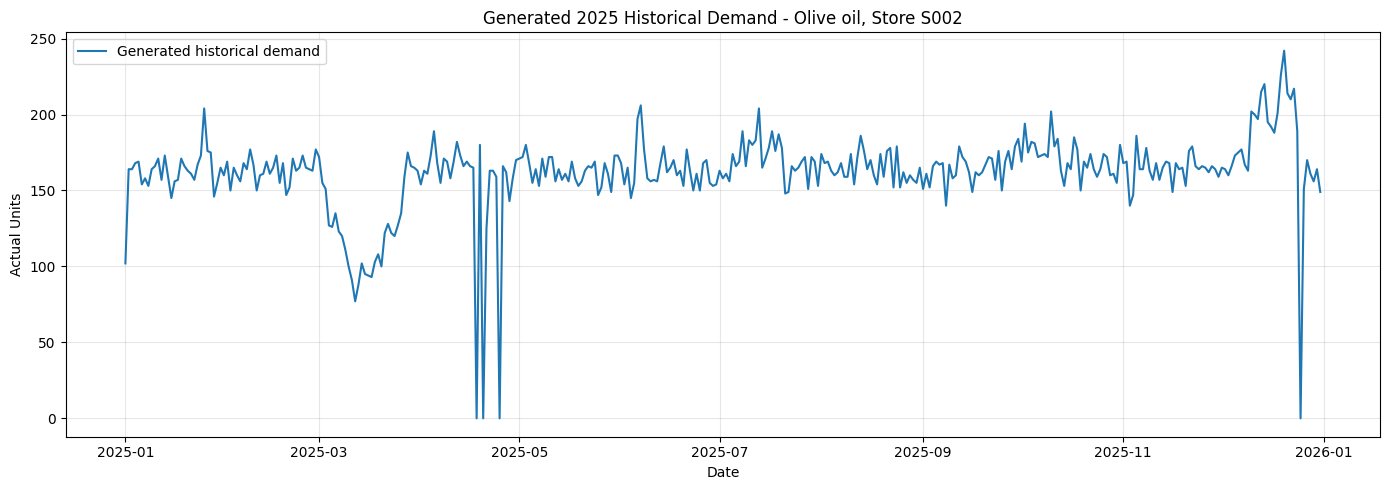

In [18]:
plot_product = "Olive oil"
plot_store = "S002"

plot_product_id = product_dimension.loc[
    product_dimension["product_name"] == plot_product,
    "product_id"
].iloc[0]

plot_data = demand_actuals[
    (demand_actuals["product_id"] == plot_product_id)
    & (demand_actuals["store_id"] == plot_store)
].copy()

plt.figure(figsize=(14, 5))

plt.plot(
    plot_data["date"],
    plot_data["actual_units"],
    linewidth=1.5,
    label="Generated historical demand"
)

plt.title(f"Generated 2025 Historical Demand - {plot_product}, Store {plot_store}")
plt.xlabel("Date")
plt.ylabel("Actual Units")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 19. Export Power BI Source Tables

Export the clean CSV files used by the Power BI report.

These files form the first version of the project data model:

- `demand_actuals.csv`
- `stores.csv`
- `products.csv`
- `calendar.csv`
- `calendar_events.csv`

The separate forecasting notebook will create `demand_forecast.csv`.


In [19]:
demand_actuals.to_csv(OUTPUT_DIR / "demand_actuals.csv", index=False)
store_dimension.to_csv(OUTPUT_DIR / "stores.csv", index=False)
product_dimension.to_csv(OUTPUT_DIR / "products.csv", index=False)
calendar_dimension.to_csv(OUTPUT_DIR / "calendar.csv", index=False)
calendar_events.to_csv(OUTPUT_DIR / "calendar_events.csv", index=False)

print("Synthetic retail demand tables created successfully.")
print("Date range:", demand_actuals["date"].min(), "to", demand_actuals["date"].max())
print("Demand rows:", len(demand_actuals))
print("Stores:", store_dimension["store_id"].nunique())
print("Products:", product_dimension["product_id"].nunique())
print("Output files:")
print("- demand_actuals.csv")
print("- stores.csv")
print("- products.csv")
print("- calendar.csv")
print("- calendar_events.csv")


Synthetic retail demand tables created successfully.
Date range: 2025-01-01 00:00:00 to 2025-12-31 00:00:00
Demand rows: 10950
Stores: 3
Products: 10
Output files:
- demand_actuals.csv
- stores.csv
- products.csv
- calendar.csv
- calendar_events.csv
